# Domain Shift Visualization (KR vs JMDC/UKB)

이 노트북은 `Composite Delphi` 학습/평가 데이터 간 도메인 시프트를 빠르게 점검하기 위한 분석용 템플릿입니다.

- 이벤트/환자 기본 통계
- AGE / DOSE / DURATION 분포 비교
- DATA 토큰 분포 비교
- JSD / Wasserstein 기반 거리 지표
- 환자 단위 feature PCA 시각화 + 도메인 분리도(AUC)


In [ ]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

plt.rcParams["font.family"] = 'Helvetica'

import sys
sys.path.append('..')
from utils import get_p2i_composite

try:
    from scipy.stats import wasserstein_distance
except Exception:
    wasserstein_distance = None

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# plt.style.use('default')
np.random.seed(42)


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [4]:
PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = (PROJECT_ROOT / '../../data').resolve()

# 필요 시 경로만 바꿔서 재사용하세요.
DOMAIN_PATHS = {
    # 'kr_train': DATA_ROOT / 'dose/kr_train.bin',
    # 'kr_val': DATA_ROOT / 'dose/kr_val.bin',
    # 'kr_test': DATA_ROOT / 'dose/kr_test.bin',
    'KOR': DATA_ROOT / 'kr_all.bin',
    'JMDC': DATA_ROOT / 'JMDC_extval.bin',
    'UKB': DATA_ROOT / 'UKB_extval.bin',
}

INCLUDE_UKB = True

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_ROOT   :', DATA_ROOT)
for k, v in DOMAIN_PATHS.items():
    print(f'{k:>8}: {v} | exists={v.exists()}')


PROJECT_ROOT: /Users/seungha/Desktop/KHU/Lab/27_transformer/GPT-Disease-Drug-Prediction/figure
DATA_ROOT   : /Users/seungha/Desktop/KHU/Lab/27_transformer/data
     KOR: /Users/seungha/Desktop/KHU/Lab/27_transformer/data/kr_all.bin | exists=True
    JMDC: /Users/seungha/Desktop/KHU/Lab/27_transformer/data/JMDC_extval.bin | exists=True
     UKB: /Users/seungha/Desktop/KHU/Lab/27_transformer/data/UKB_extval.bin | exists=True


In [5]:
COMPOSITE_DTYPE = np.dtype([
    ('ID', np.uint32),
    ('AGE', np.uint32),
    ('DATA', np.uint32),
    ('DOSE', np.float32),
    ('DURATION', np.uint32),
])

DRUG_TOKEN_MIN = 1278  # apply_token_shift=False 기준
DRUG_TOKEN_MAX = 1288

def load_domain(path: Path):
    arr = np.fromfile(path, dtype=COMPOSITE_DTYPE)
    p2i = get_p2i_composite(arr)
    return arr, p2i

def js_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    p = p / max(p.sum(), eps)
    q = q / max(q.sum(), eps)
    m = 0.5 * (p + q)
    def _kl(a, b):
        a = np.clip(a, eps, None)
        b = np.clip(b, eps, None)
        return np.sum(a * np.log(a / b))
    return 0.5 * _kl(p, m) + 0.5 * _kl(q, m)

def normalized_hist(x, bins):
    h, _ = np.histogram(x, bins=bins)
    h = h.astype(np.float64)
    s = h.sum()
    return h / s if s > 0 else h


In [7]:
domains = {}
for name, path in DOMAIN_PATHS.items():
    if (not INCLUDE_UKB) and name == 'UKB':
        continue
    if not path.exists():
        print(f'[skip] {name}: missing {path}')
        continue
    data, p2i = load_domain(path)
    domains[name] = {'data': data, 'p2i': p2i, 'path': path}
    print(f'[ok] {name}: events={len(data):,}, patients={len(p2i):,}')

assert 'KOR' in domains, 'KOR is required as reference domain.'

[ok] KOR: events=25,699,691, patients=107,658
[ok] JMDC: events=335,296,018, patients=2,197,367
[ok] UKB: events=1,596,561, patients=51,072


In [8]:
def summarize_domain(data, p2i):
    ages = data['AGE'].astype(np.float64) / 365.25
    dose = data['DOSE'].astype(np.float64)
    dur = data['DURATION'].astype(np.float64)
    token = data['DATA'].astype(np.int64)
    drug_mask = (token >= DRUG_TOKEN_MIN) & (token <= DRUG_TOKEN_MAX)

    lengths = p2i[:, 1].astype(np.int64) if len(p2i) > 0 else np.array([0])
    pos_dose = dose[dose > 0]

    out = {
        'n_events': int(len(data)),
        'n_patients': int(len(p2i)),
        'events_per_patient_mean': float(lengths.mean()),
        'events_per_patient_median': float(np.median(lengths)),
        'age_mean': float(ages.mean()),
        'age_std': float(ages.std()),
        'age_p95': float(np.percentile(ages, 95)),
        'dose_mean': float(dose.mean()),
        'dose_nonzero_rate': float((dose > 0).mean()),
        'dose_positive_mean': float(pos_dose.mean()) if len(pos_dose) else 0.0,
        'duration_mean': float(dur.mean()),
        'duration_p95': float(np.percentile(dur, 95)),
        'drug_event_rate': float(drug_mask.mean()),
        'unique_data_tokens': int(np.unique(token).size),
    }
    return out

summary_rows = []
for name, obj in domains.items():
    row = {'domain': name}
    row.update(summarize_domain(obj['data'], obj['p2i']))
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('domain').sort_index()
summary_df

,n_events,n_patients,events_per_patient_mean,events_per_patient_median,age_mean,age_std,age_p95,dose_mean,dose_nonzero_rate,dose_positive_mean,duration_mean,duration_p95,drug_event_rate,unique_data_tokens
domain,,,,,,,,,,,,,,
JMDC,335296018,2197367,152.589903,87.0,53.446681,10.605009,69.166324,0.309962,0.090750,3.415558,3.325469,30.0,0.090777,1158
KOR,25699691,107658,238.716036,190.0,64.765015,12.193031,82.154689,0.377615,0.223737,1.687763,7.073512,30.0,0.224016,1192
UKB,1596561,51072,31.260984,28.0,59.350964,16.042240,77.716632,0.000000,0.000000,0.000000,0.000000,0.0,0.025849,1206


In [ ]:
color_map = {
    'KOR': '#558387',
    'JMDC': '#bb372a',
    'UKB': "#ce9c3e",
}

## 1) AGE / trajectory length distribution

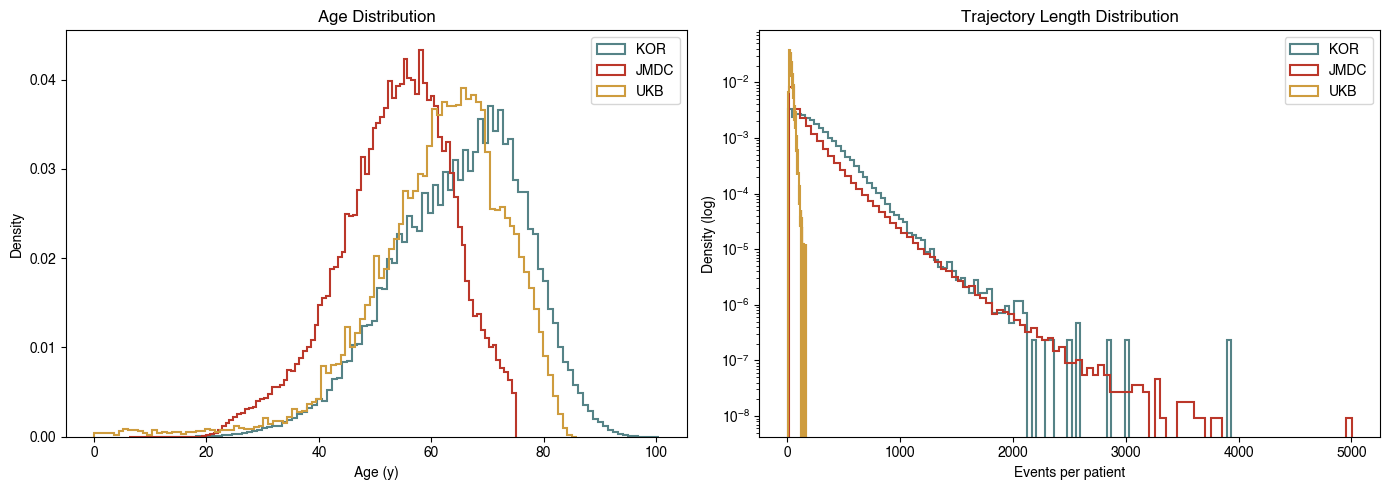

In [ ]:
legend_order = ['KOR', 'JMDC', 'UKB']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, obj in domains.items():
    ages_year = obj['data']['AGE'].astype(np.float64) / 365.25
    ages_year = ages_year[ages_year > 0] 
    axes[0].hist(ages_year, bins=100, histtype='step', density=True, linewidth=1.5, label=name, color=color_map[name])

    lengths = obj['p2i'][:, 1].astype(np.int64)
    axes[1].hist(lengths, bins=100, histtype='step', density=True, linewidth=1.5, label=name, color=color_map[name])

axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (y)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].set_title('Trajectory Length Distribution')
axes[1].set_xlabel('Events per patient')
axes[1].set_ylabel('Density (log)')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()


## 2) DOSE / DURATION distribution

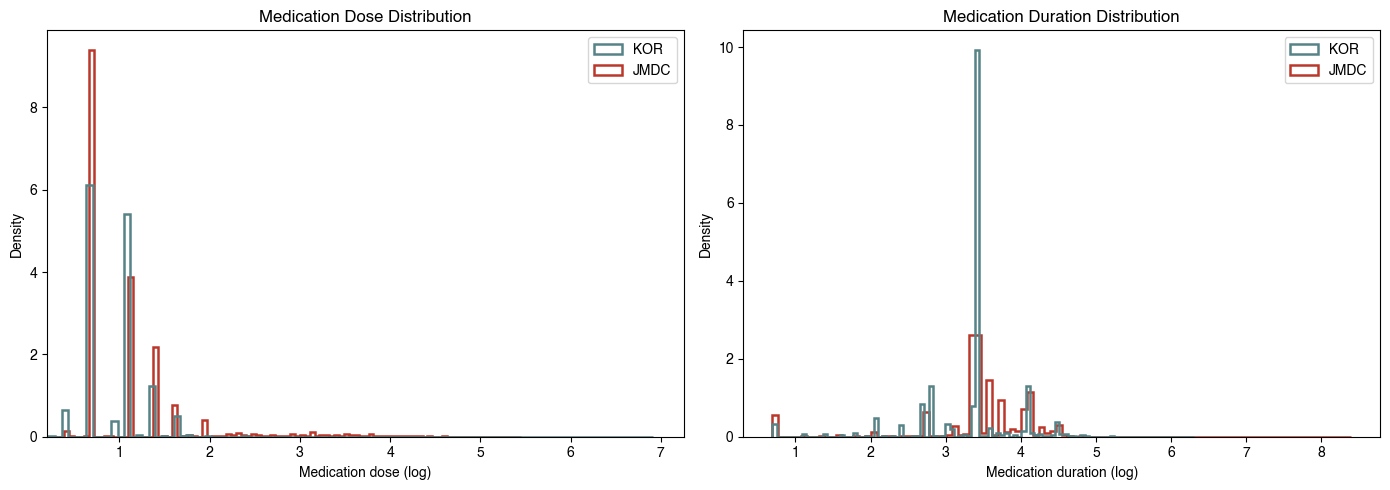

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_order = ['JMDC', 'KOR']

for name in plot_order:
    obj = domains[name]
    dose = obj['data']['DOSE'].astype(np.float64)
    dur = obj['data']['DURATION'].astype(np.float64)

    dose = dose[dose > 0.01]
    dur = dur[dur > 0]

    dose_plot = np.log1p(np.clip(dose, a_min=0.0, a_max=None))
    dur_plot = np.log1p(np.clip(dur, a_min=0.0, a_max=None))

    axes[0].hist(dose_plot, bins=100, histtype='step', density=True, linewidth=1.8, label=name, color=color_map[name])
    axes[1].hist(dur_plot, bins=100, histtype='step', density=True, linewidth=1.8, label=name, color=color_map[name])

axes[0].set_title('Medication Dose Distribution')
axes[0].set_xlim([0.2, None])
axes[0].set_xlabel('Medication dose (log)')
axes[0].set_ylabel('Density')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[::-1], labels[::-1])
# axes[0].legend()

axes[1].set_title('Medication Duration Distribution')
axes[1].set_xlabel('Medication duration (log)')
axes[1].set_ylabel('Density')
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[::-1], labels[::-1])
# axes[1].legend()

plt.tight_layout()
plt.show()


## 3) DATA token distribution shift

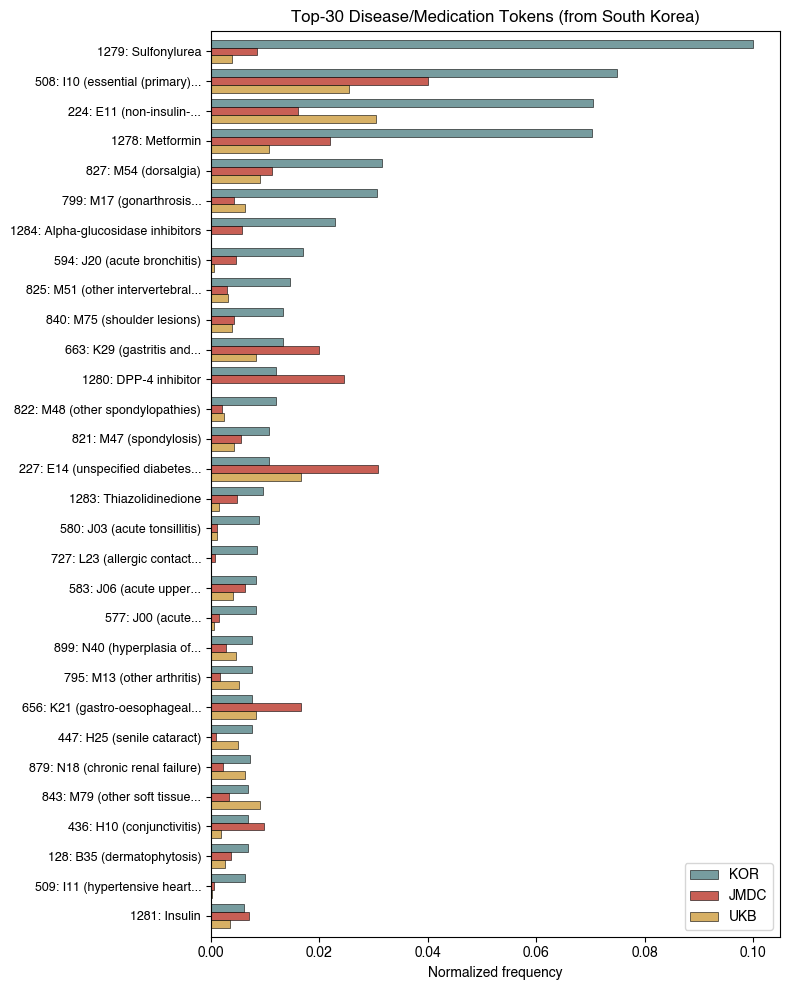

In [48]:
# reference top tokens from KR train
ref_token = domains['KOR']['data']['DATA'].astype(np.int64)
ref_counts = np.bincount(ref_token)
start_token = 22
top_k = 30

valid_tokens = np.arange(start_token, len(ref_counts))
valid_counts = ref_counts[start_token:]
top_tokens = valid_tokens[np.argsort(valid_counts)[-top_k:][::-1]]

# labels.csv 로드 (index == token id)
label_path = Path("../../data/labels.csv")
labels_df = pd.read_csv(label_path, header=None, usecols=[0], names=['name'])
labels_df['name'] = labels_df['name'].astype(str).str.strip().str.rstrip(',')
token_to_name = labels_df['name'].to_dict()  # key: token id (0-based)

def token_label(t):
    name = token_to_name.get(int(t), f"UNK_{int(t)}")
    name = textwrap.shorten(name, width=28, placeholder="...")
    return f"{int(t)}: {name}"

y_labels = [token_label(t) for t in top_tokens]

freq_table = {}
for name, obj in domains.items():
    token = obj['data']['DATA'].astype(np.int64)
    cnt = np.bincount(token, minlength=max(ref_counts.shape[0], top_tokens.max() + 1)).astype(np.float64)
    freq = cnt / max(cnt.sum(), 1.0)
    freq_table[name] = freq[top_tokens]

y = np.arange(top_k)
fig, ax = plt.subplots(figsize=(8, 10))
height = 0.8 / max(len(freq_table), 1)

for i, (name, freq) in enumerate(freq_table.items()):
    ax.barh(
        y + i * height,
        freq,
        height=height,
        label=name,
        alpha=0.8,
        color=color_map[name],
        edgecolor='black',
        linewidth=0.5
    )

ax.set_title(f"Top-{top_k} Disease/Medication Tokens (from South Korea)")
ax.set_xlabel("Normalized frequency")
# ax.set_ylabel("Token ID : Label")

ax.set_yticks(y + height * (len(freq_table) - 1) / 2)
ax.set_yticklabels(y_labels, fontsize=9)
ax.invert_yaxis()
ax.margins(y=0.01)

ax.legend()
plt.tight_layout()
plt.show()

## 4) Distance metrics (vs KR train)

In [33]:
ref = domains['KOR']['data']
ref_token = ref['DATA'].astype(np.int64)
ref_dose = np.log1p(np.clip(ref['DOSE'].astype(np.float64), a_min=0.0, a_max=None))
ref_dur = np.log1p(np.clip(ref['DURATION'].astype(np.float64), a_min=0.0, a_max=None))

token_bins = np.arange(max(int(ref_token.max()) + 2, 1300))
dose_bins = np.linspace(0.0, max(np.percentile(ref_dose, 99.9), 1.0), 120)
dur_bins = np.linspace(0.0, max(np.percentile(ref_dur, 99.9), 1.0), 120)

ref_token_h = normalized_hist(ref_token, token_bins)
ref_dose_h = normalized_hist(ref_dose, dose_bins)
ref_dur_h = normalized_hist(ref_dur, dur_bins)

rows = []
for name, obj in domains.items():
    if name == 'KOR':
        continue
    d = obj['data']
    token = d['DATA'].astype(np.int64)
    dose = np.log1p(np.clip(d['DOSE'].astype(np.float64), a_min=0.0, a_max=None))
    dur = np.log1p(np.clip(d['DURATION'].astype(np.float64), a_min=0.0, a_max=None))

    token_h = normalized_hist(token, token_bins)
    dose_h = normalized_hist(dose, dose_bins)
    dur_h = normalized_hist(dur, dur_bins)

    row = {
        'domain': name,
        'jsd_data_token': float(js_divergence(ref_token_h, token_h)),
        'jsd_dose_log1p': float(js_divergence(ref_dose_h, dose_h)),
        'jsd_duration_log1p': float(js_divergence(ref_dur_h, dur_h)),
    }
    if wasserstein_distance is not None:
        row['wasserstein_dose_log1p'] = float(wasserstein_distance(ref_dose, dose))
        row['wasserstein_duration_log1p'] = float(wasserstein_distance(ref_dur, dur))
    else:
        row['wasserstein_dose_log1p'] = np.nan
        row['wasserstein_duration_log1p'] = np.nan
    rows.append(row)

dist_df = pd.DataFrame(rows).set_index('domain').sort_values('jsd_data_token')
dist_df

,jsd_data_token,jsd_dose_log1p,jsd_duration_log1p,wasserstein_dose_log1p,wasserstein_duration_log1p
domain,,,,,
JMDC,0.188939,0.023522,0.041145,0.131126,0.431392
UKB,0.236183,0.084318,0.084378,0.210070,0.741620


## 5) Patient-level feature space (PCA)

In [ ]:
def patient_feature_matrix(data, p2i, max_patients=None, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    if len(p2i) == 0:
        return np.zeros((0, 9), dtype=np.float32)

    idx = np.arange(len(p2i))
    if (max_patients is not None) and (len(idx) > max_patients):
        idx = rng.choice(idx, size=max_patients, replace=False)

    feats = []
    for i in idx:
        s, l = p2i[i]
        rec = data[s:s+l]

        age = rec['AGE'].astype(np.float64) / 365.25
        token = rec['DATA'].astype(np.int64)
        dose = np.clip(rec['DOSE'].astype(np.float64), a_min=0.0, a_max=None)
        dur = rec['DURATION'].astype(np.float64)

        gaps = np.diff(age) if len(age) > 1 else np.array([0.0])
        drug_mask = (token >= DRUG_TOKEN_MIN) & (token <= DRUG_TOKEN_MAX)

        uniq, cnt = np.unique(token, return_counts=True)
        p = cnt.astype(np.float64) / max(cnt.sum(), 1.0)
        entropy = -np.sum(p * np.log(p + 1e-12))

        feats.append([
            float(len(rec)),
            float(age.min()) if len(age) else 0.0,
            float(age.max()) if len(age) else 0.0,
            float(age.max() - age.min()) if len(age) else 0.0,
            float(np.mean(gaps)),
            float(np.log1p(dose).mean()),
            float(np.log1p(np.clip(dur, a_min=0.0, a_max=None)).mean()),
            float(drug_mask.mean()),
            float(entropy),
        ])

    return np.asarray(feats, dtype=np.float32)

X_list = []
y_list = []
for i, (name, obj) in enumerate(domains.items()):
    X_dom = patient_feature_matrix(obj['data'], 
                                   obj['p2i'], 
                                   max_patients=None, 
                                   rng_seed=42 + i)
    X_list.append(X_dom)
    y_list.append(np.full(len(X_dom), name, dtype=object))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

pca = make_pipeline(StandardScaler(), PCA(n_components=2, random_state=42))
Z = pca.fit_transform(X)

legend_order = ['KOR', 'JMDC', 'UKB']

plt.figure(figsize=(7, 6))
ax = plt.gca()

for name in legend_order:
    m = (y == name)
    if not np.any(m):
        continue
    ax.scatter(
        Z[m, 0], Z[m, 1],
        s=10, alpha=0.15,
        c=color_map[name],
        label=name,
        edgecolor='none',
        # linewidth=0.3
    )

# ax.set_title('Patient-level Feature PCA')
ax.set_xticks([])
ax.set_yticks([])

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, 8)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

leg = ax.legend(markerscale=2)
for h in leg.legend_handles:
    h.set_alpha(0.8)

plt.tight_layout()
plt.show()

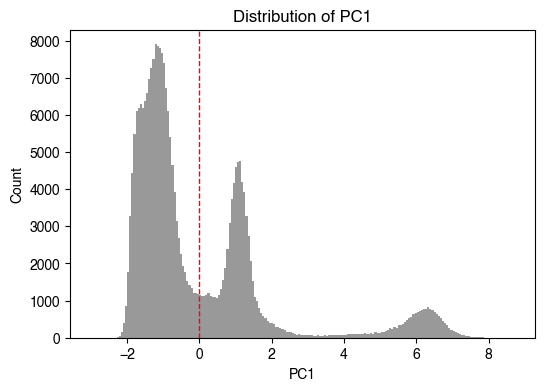

In [56]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 4))
plt.hist(Z[:, 0], bins=200, color='gray', alpha=0.8)
plt.axvline(0.0, color='red', linestyle='--', linewidth=1)
plt.xlabel("PC1")
plt.ylabel("Count")
plt.title("Distribution of PC1")
plt.show()

In [57]:
pc1_thr = 0.0
group = np.where(Z[:, 0] >= pc1_thr, "right", "left")

In [58]:
import pandas as pd

feature_names = [
    "n_records",
    "age_min",
    "age_max",
    "age_span",
    "mean_gap",
    "mean_log1p_dose",
    "mean_log1p_duration",
    "drug_ratio",
    "token_entropy",
]

df_feat = pd.DataFrame(X, columns=feature_names)
df_feat["domain"] = y
df_feat["PC1"] = Z[:, 0]
df_feat["PC2"] = Z[:, 1]
df_feat["group"] = group

summary = df_feat.groupby("group")[feature_names].mean().T
summary["diff_right_minus_left"] = summary["right"] - summary["left"]
print(summary)

group                      left       right  diff_right_minus_left
n_records            173.155014  142.529129             -30.625885
age_min                0.000000   34.056557              34.056557
age_max               64.000427   58.173405              -5.827023
age_span              64.000427   24.116850             -39.883575
mean_gap               1.227613    0.185380              -1.042233
mean_log1p_dose        0.016857    0.317993               0.301136
mean_log1p_duration    0.067950    1.116399               1.048449
drug_ratio             0.029007    0.334112               0.305104
token_entropy          3.109911    1.977565              -1.132346


In [59]:
group_domain = pd.crosstab(df_feat["domain"], df_feat["group"], normalize="index")
print(group_domain)

group     left   right
domain                
JMDC    0.5396  0.4604
KOR     0.5619  0.4381
UKB     1.0000  0.0000


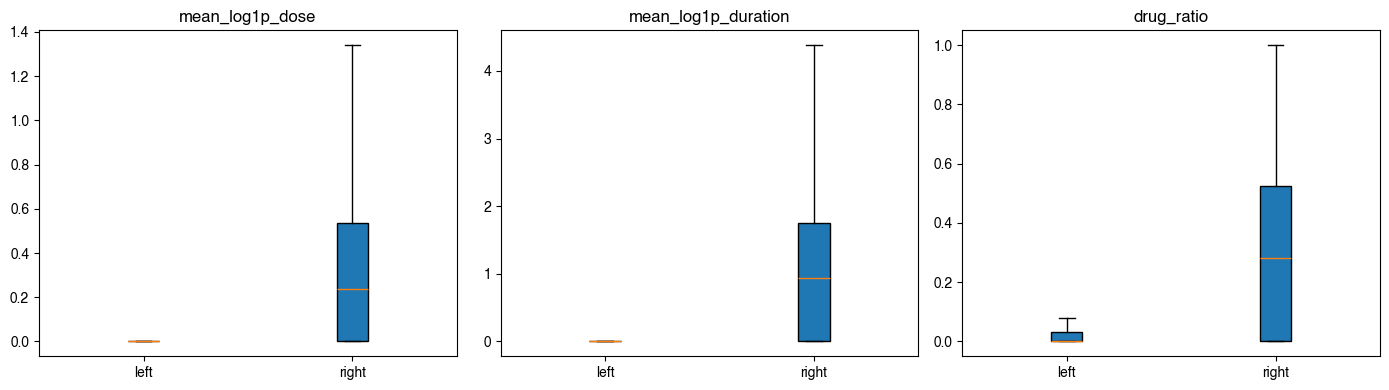

In [64]:
check_features = ["mean_log1p_dose", "mean_log1p_duration", "drug_ratio"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feat in zip(axes, check_features):
    left_vals = df_feat.loc[df_feat["group"] == "left", feat]
    right_vals = df_feat.loc[df_feat["group"] == "right", feat]

    ax.boxplot(
        [left_vals, right_vals],
        tick_labels=["left", "right"],
        patch_artist=True,
        showfliers=False
    )
    ax.set_title(feat)

plt.tight_layout()
plt.show()

In [49]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feature_names = [
    "n_records",
    "age_min",
    "age_max",
    "age_span",
    "mean_gap",
    "mean_log1p_dose",
    "mean_log1p_duration",
    "drug_ratio",
    "token_entropy",
]

# 1) scaler + PCA를 분리해서 다시 fit
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_scaled)

# 2) loadings 계산
# columns = principal components, rows = original features
loading_df = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=["PC1", "PC2"]
)

# 3) explained variance
explained_df = pd.DataFrame({
    "PC": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_
})

print("Explained variance ratio")
print(explained_df)
print("\nRaw loadings")
print(loading_df)

# 4) 절댓값 기준으로 중요도 정렬
pc1_sorted = loading_df["PC1"].abs().sort_values(ascending=False)
pc2_sorted = loading_df["PC2"].abs().sort_values(ascending=False)

print("\nTop contributors to PC1")
print(loading_df.loc[pc1_sorted.index, ["PC1"]])

print("\nTop contributors to PC2")
print(loading_df.loc[pc2_sorted.index, ["PC2"]])

Explained variance ratio
    PC  explained_variance_ratio
0  PC1                  0.473938
1  PC2                  0.230119

Raw loadings
                          PC1       PC2
n_records           -0.047197  0.442679
age_min              0.383978 -0.280518
age_max             -0.052126  0.467794
age_span            -0.346040  0.461712
mean_gap            -0.188367  0.011867
mean_log1p_dose      0.410444  0.300300
mean_log1p_duration  0.417751  0.300445
drug_ratio           0.419941  0.302365
token_entropy       -0.416005  0.146023

Top contributors to PC1
                          PC1
drug_ratio           0.419941
mean_log1p_duration  0.417751
token_entropy       -0.416005
mean_log1p_dose      0.410444
age_min              0.383978
age_span            -0.346040
mean_gap            -0.188367
age_max             -0.052126
n_records           -0.047197

Top contributors to PC2
                          PC2
age_max              0.467794
age_span             0.461712
n_records            0

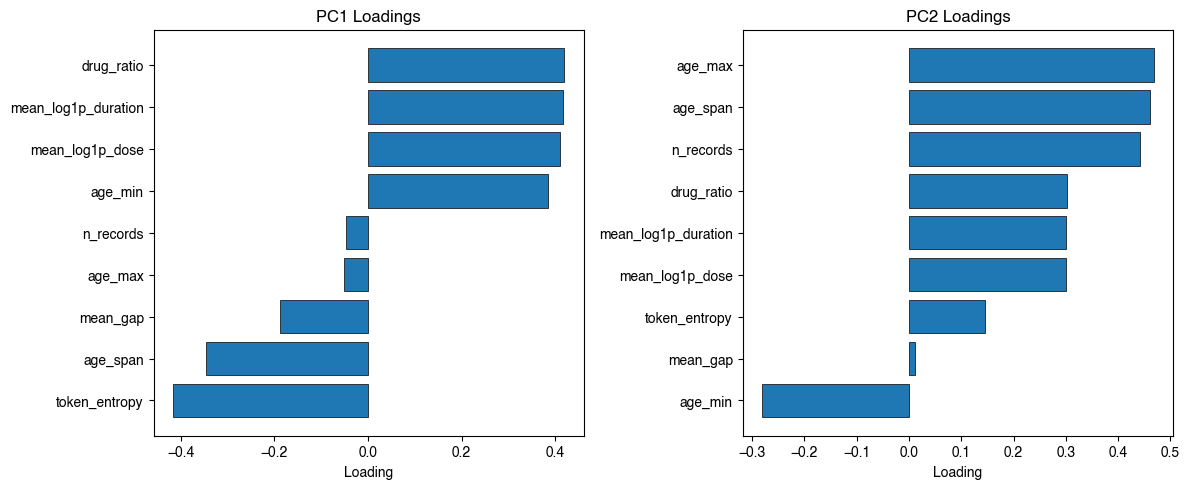

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pc1_plot = loading_df["PC1"].sort_values()
pc2_plot = loading_df["PC2"].sort_values()

axes[0].barh(pc1_plot.index, pc1_plot.values, edgecolor="black", linewidth=0.5)
axes[0].set_title("PC1 Loadings")
axes[0].set_xlabel("Loading")

axes[1].barh(pc2_plot.index, pc2_plot.values, edgecolor="black", linewidth=0.5)
axes[1].set_title("PC2 Loadings")
axes[1].set_xlabel("Loading")

plt.tight_layout()
plt.show()

## 6) Domain separability (KR train vs each domain)

In [45]:
# reuse patient features per domain
feature_by_domain = {}
for i, (name, obj) in enumerate(domains.items()):
    feature_by_domain[name] = patient_feature_matrix(obj['data'], obj['p2i'], max_patients=100000, rng_seed=123 + i)

ref_name = 'KOR'
X_ref = feature_by_domain[ref_name]

rows = []
for name, X_dom in feature_by_domain.items():
    if name == ref_name:
        continue

    n = min(len(X_ref), len(X_dom))
    if n < 100:
        continue

    X_pair = np.vstack([X_ref[:n], X_dom[:n]])
    y_pair = np.hstack([np.zeros(n, dtype=np.int64), np.ones(n, dtype=np.int64)])

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_pair, y_pair, test_size=0.25, random_state=42, stratify=y_pair
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced')
    )
    clf.fit(X_tr, y_tr)
    p = clf.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, p)

    rows.append({'target_domain': name, 'domain_auc_vs_kr_train': float(auc), 'n_per_domain': int(n)})

sep_df = pd.DataFrame(rows).sort_values('domain_auc_vs_kr_train', ascending=False)
sep_df


,target_domain,domain_auc_vs_kr_train,n_per_domain
1,UKB,0.999565,51072
0,JMDC,0.851750,100000


## 해석 가이드

- `jsd_*`, `wasserstein_*`가 클수록 분포 차이가 큽니다.
- `domain_auc_vs_kr_train`가 0.5에 가까우면 도메인 구분이 어렵고, 1.0에 가까우면 shift가 큽니다.
- JMDC에서 shift가 큰 축(예: duration tail, drug token mix)을 먼저 target해서 domain adaptation 전략을 설계하세요.


## 7) Conditional Shift Probe (P(y|x) shift)

아래 섹션은 KR vs JMDC에서 **같은 x 조건에서 y(dose/duration)가 달라지는지**를 점검합니다.

- Reweighting test (KR을 JMDC의 x 분포로 보정)
- Same-score curve (같은 예측점수 구간에서의 평균 y 비교)
- Matched pair test (x 최근접 매칭 후 y 차이)


In [49]:
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

def build_drug_event_table(data, p2i):
    rows = []
    for (start, length) in p2i:
        rec = data[start:start+length]
        drug_count = 0
        for i in range(length):
            tok = int(rec['DATA'][i])
            if not (DRUG_TOKEN_MIN <= tok <= DRUG_TOKEN_MAX):
                continue

            age = float(rec['AGE'][i]) / 365.25
            dose = float(max(rec['DOSE'][i], 0.0))
            dur = float(rec['DURATION'][i])

            if i > 0:
                prev_age = float(rec['AGE'][i-1]) / 365.25
                prev_gap = max(age - prev_age, 0.0)
                prev_tok = int(rec['DATA'][i-1])
                prev_dose = float(max(rec['DOSE'][i-1], 0.0))
                prev_dur = float(rec['DURATION'][i-1])
            else:
                prev_gap = 0.0
                prev_tok = 0
                prev_dose = 0.0
                prev_dur = 0.0

            drug_count += 1
            pos_norm = float(i / max(length - 1, 1))
            drug_rate_so_far = float(drug_count / (i + 1))

            rows.append({
                'token': tok,
                'age': age,
                'prev_gap': prev_gap,
                'prev_tok': prev_tok,
                'prev_dose': prev_dose,
                'prev_dur': prev_dur,
                'event_pos_norm': pos_norm,
                'drug_rate_so_far': drug_rate_so_far,
                'traj_len': float(length),
                'dose_y': dose,
                'dur_y': dur,
            })

    return pd.DataFrame(rows)

def _safe_rmse(y, p, w=None):
    y = np.asarray(y, dtype=np.float64)
    p = np.asarray(p, dtype=np.float64)
    if w is None:
        return float(np.sqrt(mean_squared_error(y, p)))
    w = np.asarray(w, dtype=np.float64)
    e2 = (y - p) ** 2
    return float(np.sqrt(np.average(e2, weights=w)))

def _binned_curve(pred, y, n_bins=10):
    pred = np.asarray(pred, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    qs = np.linspace(0, 1, n_bins + 1)
    bins = np.quantile(pred, qs)
    bins = np.unique(bins)
    if len(bins) < 3:
        return pd.DataFrame(columns=['bin_left', 'bin_right', 'mean_pred', 'mean_y', 'n'])

    idx = np.digitize(pred, bins[1:-1], right=False)
    rows = []
    for b in range(len(bins) - 1):
        m = idx == b
        if m.sum() == 0:
            continue
        rows.append({
            'bin_left': float(bins[b]),
            'bin_right': float(bins[b + 1]),
            'mean_pred': float(pred[m].mean()),
            'mean_y': float(y[m].mean()),
            'n': int(m.sum()),
        })
    return pd.DataFrame(rows)

def conditional_shift_probe(X_kr, y_kr, X_jm, y_jm, random_state=42):
    # Domain classifier: p(domain=JMDC | x)
    X_dom = np.vstack([X_kr, X_jm])
    d_dom = np.hstack([np.zeros(len(X_kr), dtype=np.int64), np.ones(len(X_jm), dtype=np.int64)])

    dom_clf = HistGradientBoostingClassifier(max_depth=6, learning_rate=0.05, max_iter=300, random_state=random_state)
    dom_clf.fit(X_dom, d_dom)
    dom_prob = dom_clf.predict_proba(X_dom)[:, 1]
    auc_domain = roc_auc_score(d_dom, dom_prob)

    # KR-only y model
    y_model = HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05, max_iter=400, random_state=random_state)
    y_model.fit(X_kr, y_kr)

    p_kr = y_model.predict(X_kr)
    p_jm = y_model.predict(X_jm)

    # Importance weighting KR -> JMDC(x): w = p(domain=JMDC|x) / p(domain=KR|x)
    pj_kr = np.clip(dom_clf.predict_proba(X_kr)[:, 1], 1e-4, 1.0 - 1e-4)
    w_kr_to_jm = np.clip(pj_kr / (1.0 - pj_kr), 0.05, 20.0)

    # Main metrics
    rmse_kr = _safe_rmse(y_kr, p_kr)
    rmse_kr_rw = _safe_rmse(y_kr, p_kr, w=w_kr_to_jm)
    rmse_jm = _safe_rmse(y_jm, p_jm)

    mae_kr = float(mean_absolute_error(y_kr, p_kr))
    mae_jm = float(mean_absolute_error(y_jm, p_jm))

    # Same-score curves
    curve_kr = _binned_curve(p_kr, y_kr, n_bins=10)
    curve_jm = _binned_curve(p_jm, y_jm, n_bins=10)

    # Matched pair (nearest neighbors in x)
    scaler = StandardScaler()
    X_kr_s = scaler.fit_transform(X_kr)
    X_jm_s = scaler.transform(X_jm)
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(X_kr_s)
    _, idx = nn.kneighbors(X_jm_s, return_distance=True)
    y_kr_match = y_kr[idx[:, 0]]
    delta = y_jm - y_kr_match

    summary = {
        'auc_domain_from_x': float(auc_domain),
        'rmse_kr_raw': rmse_kr,
        'rmse_kr_reweighted_to_jmdc_x': rmse_kr_rw,
        'rmse_jmdc': rmse_jm,
        'rmse_gap_after_reweight': float(rmse_jm - rmse_kr_rw),
        'mae_kr_raw': mae_kr,
        'mae_jmdc': mae_jm,
        'matched_delta_mean_jmdc_minus_kr': float(delta.mean()),
        'matched_delta_std': float(delta.std()),
        'matched_delta_p05': float(np.percentile(delta, 5)),
        'matched_delta_p50': float(np.percentile(delta, 50)),
        'matched_delta_p95': float(np.percentile(delta, 95)),
    }

    return summary, curve_kr, curve_jm


In [ ]:
assert 'KOR' in domains and 'JMDC' in domains, 'KOR and JMDC must be loaded.'

df_kr = build_drug_event_table(domains['KOR']['data'], domains['KOR']['p2i'])
df_jm = build_drug_event_table(domains['JMDC']['data'], domains['JMDC']['p2i'])

print('KOR drug events :', len(df_kr))
print('JMDC drug events:', len(df_jm))

feature_cols = [
    'token', 'age', 'prev_gap', 'prev_tok', 'prev_dose', 'prev_dur',
    'event_pos_norm', 'drug_rate_so_far', 'traj_len'
]

X_kr = df_kr[feature_cols].to_numpy(dtype=np.float32)
X_jm = df_jm[feature_cols].to_numpy(dtype=np.float32)

# DOSE probe (log1p scale)
y_dose_kr = np.log1p(np.clip(df_kr['dose_y'].to_numpy(dtype=np.float64), a_min=0.0, a_max=None))
y_dose_jm = np.log1p(np.clip(df_jm['dose_y'].to_numpy(dtype=np.float64), a_min=0.0, a_max=None))

dose_summary, dose_curve_kr, dose_curve_jm = conditional_shift_probe(X_kr, y_dose_kr, X_jm, y_dose_jm)

# DURATION probe (log1p scale)
y_dur_kr = np.log1p(np.clip(df_kr['dur_y'].to_numpy(dtype=np.float64), a_min=0.0, a_max=None))
y_dur_jm = np.log1p(np.clip(df_jm['dur_y'].to_numpy(dtype=np.float64), a_min=0.0, a_max=None))

dur_summary, dur_curve_kr, dur_curve_jm = conditional_shift_probe(X_kr, y_dur_kr, X_jm, y_dur_jm)

probe_df = pd.DataFrame([
    {'target': 'dose_log1p', **dose_summary},
    {'target': 'duration_log1p', **dur_summary},
]).set_index('target')
probe_df


KOR drug events : 5757144
JMDC drug events: 30437277


In [ ]:
def plot_same_score_curve(curve_kr, curve_jm, title):
    c1 = curve_kr.copy()
    c2 = curve_jm.copy()
    if len(c1) == 0 or len(c2) == 0:
        print('[warn] empty curve')
        return

    plt.figure(figsize=(7, 5))
    plt.plot(c1['mean_pred'], c1['mean_y'], marker='o', label='KR')
    plt.plot(c2['mean_pred'], c2['mean_y'], marker='o', label='JMDC')
    plt.xlabel('Predicted score bin mean')
    plt.ylabel('Observed y mean')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_same_score_curve(dose_curve_kr, dose_curve_jm, 'Same-score curve: DOSE (log1p)')
plot_same_score_curve(dur_curve_kr, dur_curve_jm, 'Same-score curve: DURATION (log1p)')

In [ ]:
probe_df.to_csv('probe_summary.csv', index=False)

### Conditional Shift 해석 팁

- `auc_domain_from_x`가 높으면 `x` 분포 차이(covariate shift)가 큽니다.
- `rmse_kr_reweighted_to_jmdc_x`로 보정했는데도 `rmse_jmdc`가 크게 나쁘면 `P(y|x)` 차이 가능성이 큽니다.
- `matched_delta_mean_jmdc_minus_kr`가 지속적으로 음수/양수이면 같은 x에서도 처방 관행이 다를 수 있습니다.
- same-score curve에서 KR/JMDC 라인이 벌어지면 conditional shift 신호입니다.
